# Machine Learning end to end Project
This notebook includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Inferential Statistics
- Data Preprocessing
- Feature Scaling
- Multiple ML Models
- Model Evaluation
- Model Comparison
- PyCaret AutoML Workflow

In [44]:
# Install Required Libraries
# Run this only once

# !pip install pandas numpy matplotlib seaborn scikit-learn scipy pycaret[full]


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


import warnings
warnings.filterwarnings('ignore')

# Load Dataset:


In [46]:
df = pd.read_csv(r'../Data/adult.csv')

print("Number of rows and columns:")
print(df.shape)
print("\n")
print("First five records of the dataset")
df.head()

Number of rows and columns:
(48842, 15)


First five records of the dataset


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [48]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [49]:
df.duplicated().sum()

52

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df.drop('fnlwgt',axis=1,inplace=True)

In [52]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

# Convert to binary classification

In [53]:
# convert the values into categorical values
# the value >50K is decode into 1 and less then <=50K into 0
df['income'] = df['income'].apply(lambda x: 1 if x == ">50K" else 0)

#### Target Column:

In [54]:
df['income'].unique()

array([0, 1], dtype=int64)

In [55]:
df.income.value_counts()

income
0    37109
1    11681
Name: count, dtype: int64

# Descriptive Statistics

In [56]:
df.describe()

,age,educational-num,capital-gain,capital-loss,hours-per-week,income
count,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,10.078807,1080.217688,87.595573,40.425886,0.239414
std,13.708493,2.570046,7455.905921,403.209129,12.392729,0.426730
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


# Correlation Analysis

In [57]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
correlation_matrix

,age,educational-num,capital-gain,capital-loss,hours-per-week,income
age,1.000000,0.030635,0.077185,0.056838,0.071223,0.230144
educational-num,0.030635,1.000000,0.125219,0.080986,0.143915,0.332802
capital-gain,0.077185,0.125219,1.000000,-0.031475,0.082152,0.223047
capital-loss,0.056838,0.080986,-0.031475,1.000000,0.054431,0.147542
hours-per-week,0.071223,0.143915,0.082152,0.054431,1.000000,0.227664
income,0.230144,0.332802,0.223047,0.147542,0.227664,1.000000


In [58]:
df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [59]:
df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [60]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
correlation_matrix

,age,educational-num,capital-gain,capital-loss,hours-per-week,income
age,1.000000,0.030635,0.077185,0.056838,0.071223,0.230144
educational-num,0.030635,1.000000,0.125219,0.080986,0.143915,0.332802
capital-gain,0.077185,0.125219,1.000000,-0.031475,0.082152,0.223047
capital-loss,0.056838,0.080986,-0.031475,1.000000,0.054431,0.147542
hours-per-week,0.071223,0.143915,0.082152,0.054431,1.000000,0.227664
income,0.230144,0.332802,0.223047,0.147542,0.227664,1.000000


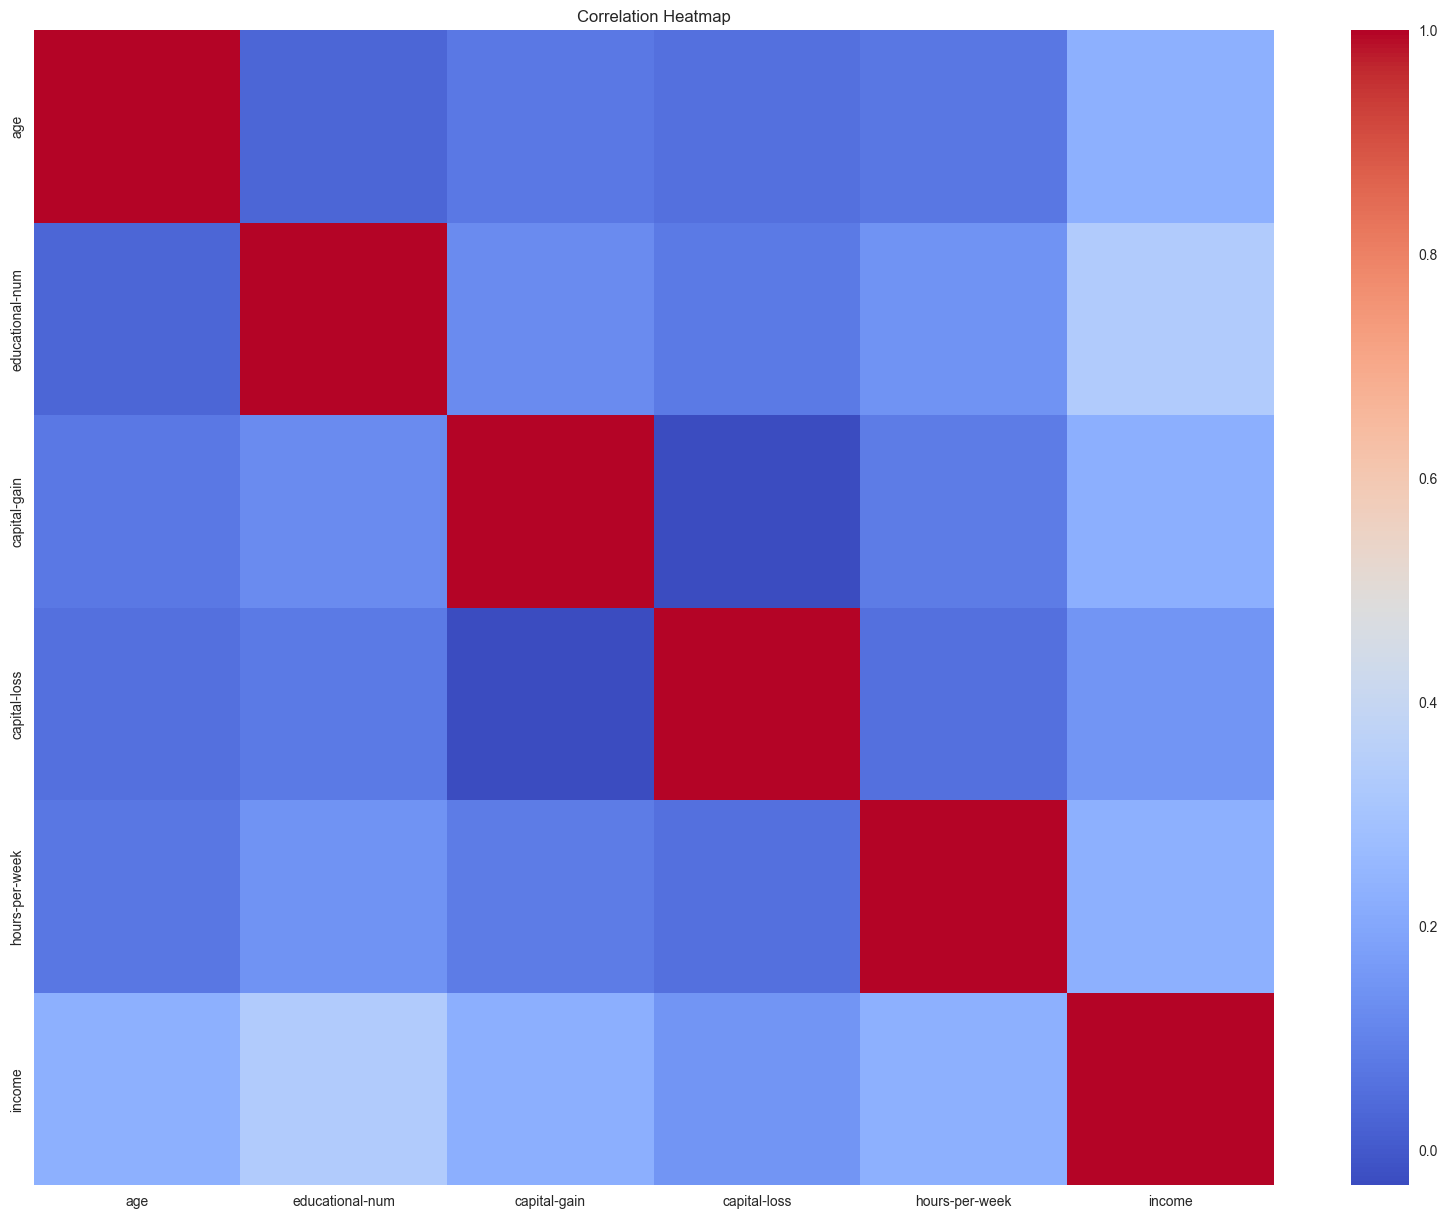

In [61]:
plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [62]:
df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [63]:
X = df.drop("income",axis=1)
y = df.income

In [64]:
y.value_counts()

income
0    37109
1    11681
Name: count, dtype: int64

# Splitting data into Train and Test sets

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [66]:
y_train.value_counts()

income
0    29669
1     9363
Name: count, dtype: int64

In [67]:
y_test.value_counts()

income
0    7440
1    2318
Name: count, dtype: int64

In [68]:
cat_cols = X_train.select_dtypes('object')
num_cols = X_train.select_dtypes('number')

In [69]:
#  Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # handle missing numbers
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # handle missing categories
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False))
])

In [70]:
preprocessor = ColumnTransformer(
                            transformers=[
                            ("num", num_pipeline, num_cols.columns),
                            ("cat", cat_pipeline, cat_cols.columns)
                            ])

In [71]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Class balancing
income
0    29669
1    29669
Name: count, dtype: int64


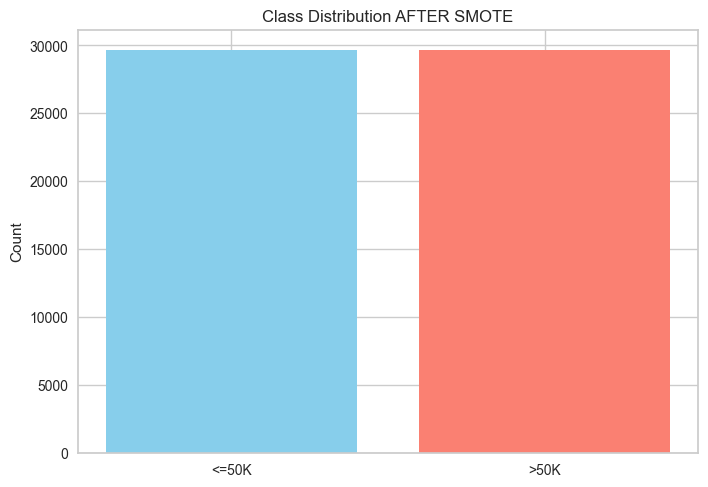

In [72]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_balance,y_train_balance= smote.fit_resample(X_train_processed,y_train)
print("Class balancing") 
print(y_train_balance.value_counts())
plt.bar(y_train_balance.value_counts().index, y_train_balance.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['<=50K', '>50K'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [73]:

results = []

def evaluate_model(name, model):


    model.fit(X_train_balance, y_train_balance)
    predictions = model.predict(X_test_processed)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n{name}")
    print("="*50)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    return model



Logistic Regression
Accuracy: 0.8101045296167247
Precision: 0.5680421422300264
Recall: 0.8373597929249353
F1 Score: 0.6768962510897995

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      7440
           1       0.57      0.84      0.68      2318

    accuracy                           0.81      9758
   macro avg       0.75      0.82      0.77      9758
weighted avg       0.85      0.81      0.82      9758

[[5964 1476]
 [ 377 1941]]


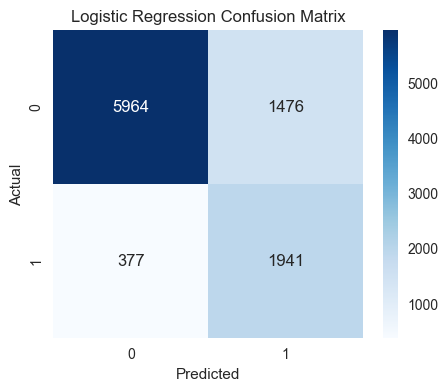

In [74]:
# Logistic Regression

lr_model = evaluate_model(
    'Logistic Regression',
     LogisticRegression()
)



Decision Tree
Accuracy: 0.8130764500922321
Precision: 0.6028309741881765
Recall: 0.6246764452113891
F1 Score: 0.6135593220338983

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      7440
           1       0.60      0.62      0.61      2318

    accuracy                           0.81      9758
   macro avg       0.74      0.75      0.75      9758
weighted avg       0.82      0.81      0.81      9758

[[6486  954]
 [ 870 1448]]


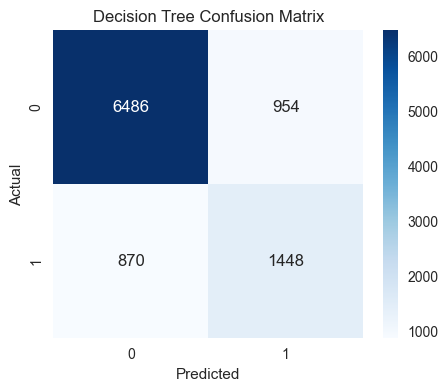

In [75]:
# Decision Tree

dt_model = evaluate_model(
    'Decision Tree',
     DecisionTreeClassifier(random_state=42)
)


SVC
Accuracy: 0.7916581266653002
Precision: 0.5387755102040817
Recall: 0.8541846419327006
F1 Score: 0.660770899382613

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7440
           1       0.54      0.85      0.66      2318

    accuracy                           0.79      9758
   macro avg       0.74      0.81      0.76      9758
weighted avg       0.85      0.79      0.80      9758

[[5745 1695]
 [ 338 1980]]


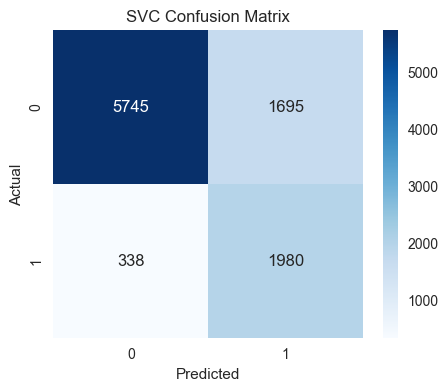

In [76]:
# Support vector machine

sv_model = evaluate_model(
    'SVC',
     SVC(kernel='linear')
)


KNN
Accuracy: 0.7974994875999181
Precision: 0.553337492202121
Recall: 0.7653149266609146
F1 Score: 0.6422881969587255

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      7440
           1       0.55      0.77      0.64      2318

    accuracy                           0.80      9758
   macro avg       0.74      0.79      0.75      9758
weighted avg       0.83      0.80      0.81      9758

[[6008 1432]
 [ 544 1774]]


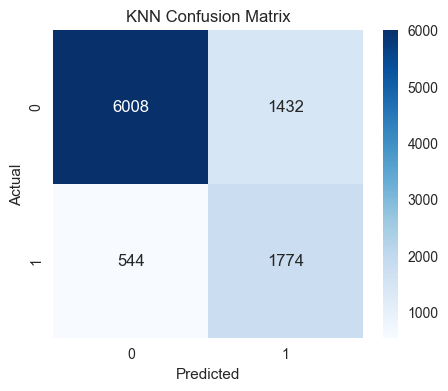

In [77]:
# K-Nearest-Neighbour

knn_model = evaluate_model(
    'KNN',
     KNeighborsClassifier(n_neighbors=5)
)

In [78]:
# !pip install pycaret

In [79]:
results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.810105,0.568042,0.837360,0.676896
1,Decision Tree,0.813076,0.602831,0.624676,0.613559
2,SVC,0.791658,0.538776,0.854185,0.660771
3,KNN,0.797499,0.553337,0.765315,0.642288


In [80]:
X_train_df = pd.DataFrame(X_train_balance)
y_train_df = pd.Series(y_train_balance, name='income')

In [84]:
# PyCaret Workflow

from pycaret.classification import *

pycaret_df = pd.concat([X_train_df, y_train_df], axis=1)

clf = setup(
    data=pycaret_df,
    target='income',
    session_id=42,
    normalize=True,
    feature_selection=False,
    remove_multicollinearity=False,
    verbose=False
)


In [85]:
# Compare All Models

best_model = compare_models(include=['lr', 'dt', 'svm', 'knn'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.8527,0.8624,0.8470,0.8568,0.8519,0.7054,0.7055,0.7140
knn,K Neighbors Classifier,0.8377,0.9045,0.8706,0.8170,0.8429,0.6755,0.6770,3.2100
lr,Logistic Regression,0.8265,0.9101,0.8549,0.8090,0.8313,0.6530,0.6541,1.8080
svm,SVM - Linear Kernel,0.8137,0.8950,0.8601,0.7872,0.8219,0.6274,0.6302,0.8760


In [86]:
final_production_pipeline = Pipeline([
    ("translator", preprocessor),  # Step 1: Takes your 13 columns and makes them 61
    ("classifier", best_model)     # Step 2: Takes the 61 columns and makes the prediction
])

final_production_pipeline.fit(X_train, y_train)
print('Full pipeline fitted successfully.')

Full pipeline fitted successfully.


In [87]:
import pickle

with open('../Backend/model.pkl', 'wb') as f:
    pickle.dump(final_production_pipeline, f)

In [88]:
with open('../backend/model.pkl', 'rb') as f:
    model = pickle.load(f)


In [89]:
model

Pipeline(memory=None,
         steps=[('translator',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  Pipeline(memory=None,
                                                           steps=[('imputer',
                                                                   SimpleImputer(add_indicator=False,
                                                                                 copy=True,
                                                                                 fill_value=None,
                                                                                 keep_empty_features=False,
                                                                                 missing_values=nan,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(copy=...
      dtype='object'))],
                                   verbose=False,
                                   verbose_feature_names_out=True)),
                ('classifier',
                 DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                        criterion='gini', max_depth=None,
                                        max_features=None, max_leaf_nodes=None,
                                        min_impurity_decrease=0.0,
                                        min_samples_leaf=1, min_samples_split=2,
                                        min_weight_fraction_leaf=0.0,
                                        monotonic_cst=None, random_state=42,
                                        splitter='best'))],
         verbose=False)